# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [4]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

 Dataset Overview

The dataset contains several features describing each passenger. These include:

- PassengerId -unique identifier for each passenger
- Survived - whether the passenger survived (1) or not (0)
- Pclass - passenger class (1st, 2nd, or 3rd class)
- Name - passenger name
- Sex - passenger gender
- Age - passenger age
- Sibsp - number of siblings or spouses traveling with the passenger
- Parch - number of parents or children traveling with the passenger
- Ticket - ticket number
- Fare - ticket price
- Cabin - cabin number
- Embarked - port of departure

These features will help determine which types of passengers were more likely to survive.

In [9]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeCatergory'],
      dtype='object')

 Age Groups Categorization

Passengers were placed into different age groups so its easier to understand the age distribution of people on the Titanic.

The groups used are:

- Child: under 13
- Teen: 13-21
- Adult: 21-40
- Middle Age: 40-60
- Senior: 60 and older

Creating these groups helps make the data easier to analyze and compare.

In [27]:
df['AgeGroup'] = ''

df.loc[df['Age'] < 13, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 13) & (df['Age'] < 21), 'AgeGroup'] = 'Teen'
df.loc[(df['Age'] >= 21) & (df['Age'] < 40), 'AgeGroup'] = 'Adult'
df.loc[(df['Age'] >= 40) & (df['Age'] < 60), 'AgeGroup'] = 'Middle Age'
df.loc[df['Age'] >= 60, 'AgeGroup'] = 'Senior'

In [28]:
df[['Age', 'AgeGroup']].head(20)

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,NaN,
6,54.0,Middle Age
7,2.0,Child
8,27.0,Adult
9,14.0,Teen


 Age Group Distribution

The bar chart shows how many passengers fall into each age group.

<AxesSubplot:>

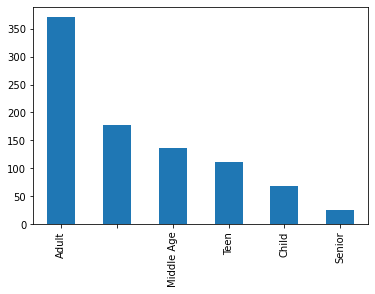

In [29]:
df['AgeGroup'].value_counts().plot(kind='bar')

Age reasoning

I grouped Age into Child, Teen, Young Adult, Middle Age, and Senior. I chose these categories to make the ages easier to interpret and compare when looking at survival patterns. Grouping age this way helps show whether younger passengers or older passengers had better chances of survival.

Fare Categories

Fare represents the price passengers paid for their ticket on the Titanic. To make the data easier to analyze, the Fare values are grouped into categories using the .loc method.
The fare categories low, medium, high, and very high ticket prices. Grouping fares helps show how ticket price may relate to passenger class and survival chances.

In [30]:
df['FareGroup'] = ''

df.loc[df['Fare'] < 10, 'FareGroup'] = 'Low Fare'
df.loc[(df['Fare'] >= 10) & (df['Fare'] < 30), 'FareGroup'] = 'Medium Fare'
df.loc[(df['Fare'] >= 30) & (df['Fare'] < 100), 'FareGroup'] = 'High Fare'
df.loc[df['Fare'] >= 100, 'FareGroup'] = 'Very High Fare'

In [31]:
df[['Fare','FareGroup']].head(20)

,Fare,FareGroup
0,7.2500,Low Fare
1,71.2833,High Fare
2,7.9250,Low Fare
3,53.1000,High Fare
4,8.0500,Low Fare
5,8.4583,Low Fare
6,51.8625,High Fare
7,21.0750,Medium Fare
8,11.1333,Medium Fare
9,30.0708,High Fare


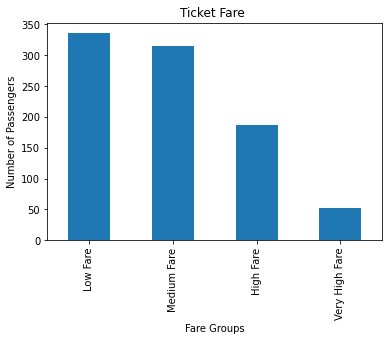

In [41]:
df['FareGroup'].value_counts().plot(kind='bar')

plt.title("Ticket Fare ")
plt.xlabel("Fare Groups")
plt.ylabel("Number of Passengers")
plt.show()

Fare Reasoning

Fare represents the ticket price paid by each passenger. Ticket price is important because it often reflects the passenger's class and level of access to resources on the ship. Passengers who paid higher fares were usually in higher classes, while those who paid lower fares were often in lower classes. People of the higher class survival rate was higher than people from the lower class due to prices of tickets they paid for. 

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

Sex Distribution

This bar graph shows how many male and female passengers were on the Titanic.  This is important because gender played a big role when women and children came first for lifeboats.

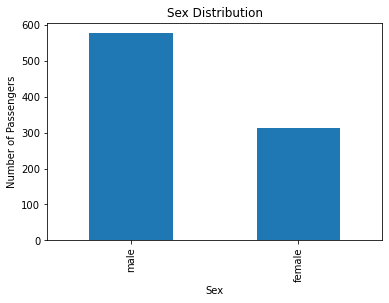

In [40]:
df['Sex'].value_counts().plot(kind='bar')

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.show()

Passenger Class Distribution

This bar graph shows how passengers were divided across the three ticket classes on the Titanic: first class, second class, and third class. Passenger class is important to analyze because it affected where passengers were located on the ship and how easily they could access lifeboats during the disaster.

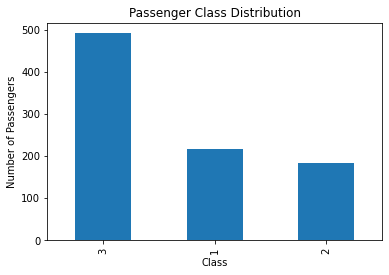

In [39]:
df['Pclass'].value_counts().plot(kind='bar')

plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Passengers")
plt.show()

Travel Companions

Travel companions are ID using the SibSp and Parch features in the dataset. SibSp represents the number of siblings or spouses traveling with the passenger, and Parch represents the number of parents or children traveling with the passenger.
By combining these two values, we can determine how many family members each passenger was traveling with on the Titanic.

In [47]:
df['TravelCompanions'] = df['SibSp'] + df['Parch']

This creates a new column called TravelCompanions that shows the total number of family members traveling with each passenger.

In [51]:
df[['SibSp','Parch','TravelCompanions']].head(20)

,SibSp,Parch,TravelCompanions
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0
5,0,0,0
6,0,0,0
7,3,1,4
8,0,2,2
9,1,0,1


In [ ]:
This will show how many siblings and parents equals a total of how many travel companions total.

Survival by Travel Companions

This bar graph shows how survival relates to the number of travel companions a passenger had. Travel companions was found by combining the SibSp and Parch features.
This visualization helps show whether passengers traveling alone or with family members had different survival outcomes during the Titanic disaster.

<Figure size 432x504 with 0 Axes>

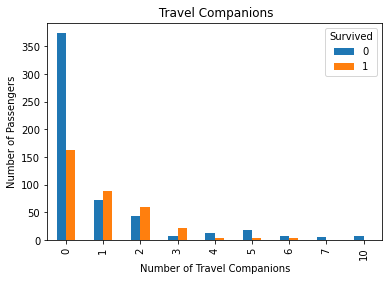

In [50]:
plt.figure(figsize=(6,7))

pd.crosstab(df['TravelCompanions'], df['Survived']).plot(kind='bar')

plt.title(" Travel Companions")
plt.xlabel("Number of Travel Companions")
plt.ylabel("Number of Passengers")

plt.show()

S = Southampton

C = Cherbourg

Q = Queenstown 
Departure

The Embarked feature represents the port where each passenger boarded the Titanic. The ports are Southampton (S), Cherbourg (C), and Queenstown (Q). This graph shows how many passengers boarded the ship from each port.

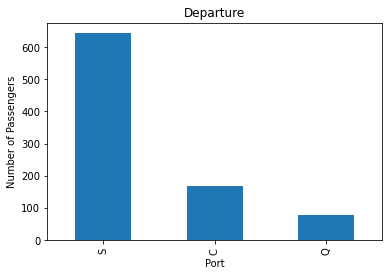

In [53]:
df['Embarked'].value_counts().plot(kind='bar')

plt.title("Departure")
plt.xlabel("Port")
plt.ylabel("Number of Passengers")
plt.show()

In [69]:
df = pd.read_csv('titanic_passengers.csv')

df.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Most Likely to Survive

One real passenger who fits the profile of someone likely to survive is Bridget O'Driscoll. She was traveling on the Titanic as a third class passenger returning to New York. Her ticket cost £7 and she boarded the ship at Southampton.
According to Encyclopedia Titanica, Bridget O'Driscoll was traveling with two other Irish passengers, Annie Jermyn and Mary Kelly. The three women shared a cabin together. All three survived the sinking of the Titanic and were able to escape the ship, although the exact lifeboat they boarded is not known. 

I used this code to find the passenger whose name contains "O'Driscoll" in the dataset. This helped me identify Bridget O'Driscoll as a real passenger that matched the profile.

In [71]:
df[df['Name'].str.contains("O'Driscoll")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
47,48,1,3,"O'Driscoll, Miss. Bridget",female,NaN,0,0,14311,7.75,NaN,Q


Least Likely to Survive

One real passenger who fits the profile of someone least likely to survive is Josefine Arnold-Franchi. She was traveling in third class and boarded the Titanic at Southampton with her husband and his cousin.
According to Encyclopedia Titanica, Josefine Arnold-Franchi died in the sinking of the Titanic. Her body, if it was recovered, was never identified.

I used this code to find the passenger whose name contains "Franchi" in the dataset. This helped me identify Bridget Franchi as a real passenger that matched the profile.

In [70]:
df[df['Name'].str.contains("Franchi")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,1,0,349237,17.8,NaN,S
353,354,0,3,"Arnold-Franchi, Mr. Josef",male,25.0,1,0,349237,17.8,NaN,S
